# Goodreads Children Books EDA

This notebook loads the Goodreads children subset, validates the interaction schema, filters sparse user-book activity, and surfaces recommendation-system insights.

This code block imports the small set of libraries needed for loading data, working with tables, and plotting the rating distribution.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

This code block defines the paths to the compressed Goodreads children metadata and interaction files.

In [2]:
DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")

BOOKS_PATH = DATA_DIR / "goodreads_books_children.json.gz"
INTERACTIONS_PATH = DATA_DIR / "goodreads_interactions_children.json.gz"

This code block loads both gzip-compressed JSON Lines files into pandas DataFrames.

In [3]:
books = pd.read_json(BOOKS_PATH, lines=True, compression="gzip")
interactions = pd.read_json(INTERACTIONS_PATH, lines=True, compression="gzip")

This code block prints the shape and column names for the book metadata dataset.

In [4]:
print("Books shape:", books.shape)
print("Books columns:")
print(list(books.columns))

Books shape: (124082, 29)
Books columns:
['isbn', 'text_reviews_count', 'series', 'country_code', 'language_code', 'popular_shelves', 'asin', 'is_ebook', 'average_rating', 'kindle_asin', 'similar_books', 'description', 'format', 'link', 'authors', 'publisher', 'num_pages', 'publication_day', 'isbn13', 'publication_month', 'edition_information', 'publication_year', 'url', 'image_url', 'book_id', 'ratings_count', 'work_id', 'title', 'title_without_series']


This code block prints the shape and column names for the user-book interactions dataset.

In [5]:
print("Interactions shape:", interactions.shape)
print("Interactions columns:")
print(list(interactions.columns))

Interactions shape: (10059349, 10)
Interactions columns:
['user_id', 'book_id', 'review_id', 'is_read', 'rating', 'review_text_incomplete', 'date_added', 'date_updated', 'read_at', 'started_at']


This code block validates that the interactions dataset has the required recommendation columns before any filtering or analysis.

In [6]:
required_interaction_columns = {"user_id", "book_id", "rating"}
missing_interaction_columns = required_interaction_columns - set(interactions.columns)

if missing_interaction_columns:
    print("Missing required interaction columns:", sorted(missing_interaction_columns))
    print("Available interaction columns:", list(interactions.columns))

assert "user_id" in interactions.columns
assert "book_id" in interactions.columns
assert "rating" in interactions.columns

This code block filters the interactions to keep users with at least 20 ratings and books with at least 50 ratings.

In [12]:
print("Original interactions shape:", interactions.shape)

user_rating_counts = interactions["user_id"].value_counts()
book_rating_counts = interactions["book_id"].value_counts()

active_users = user_rating_counts[user_rating_counts >= 20].index
popular_books = book_rating_counts[book_rating_counts >= 50].index

filtered_interactions = interactions[
    (interactions["user_id"].isin(active_users)) &
    (interactions["book_id"].isin(popular_books)) &
    (interactions["rating"] > 0)
].copy()

print("Filtered interactions shape:", filtered_interactions.shape)

Original interactions shape: (10059349, 10)
Filtered interactions shape: (4350204, 10)


This code block compares the number of unique users and books before and after filtering.

In [13]:
unique_users_before = interactions["user_id"].nunique()
unique_books_before = interactions["book_id"].nunique()

unique_users_after = filtered_interactions["user_id"].nunique()
unique_books_after = filtered_interactions["book_id"].nunique()

print("Unique users before filtering:", unique_users_before)
print("Unique users after filtering:", unique_users_after)
print("Unique books before filtering:", unique_books_before)
print("Unique books after filtering:", unique_books_after)

Unique users before filtering: 542145
Unique users after filtering: 96819
Unique books before filtering: 124082
Unique books after filtering: 22785


This code block plots exact counts for each rating value so the discrete 1-5 rating scale is easy to read.

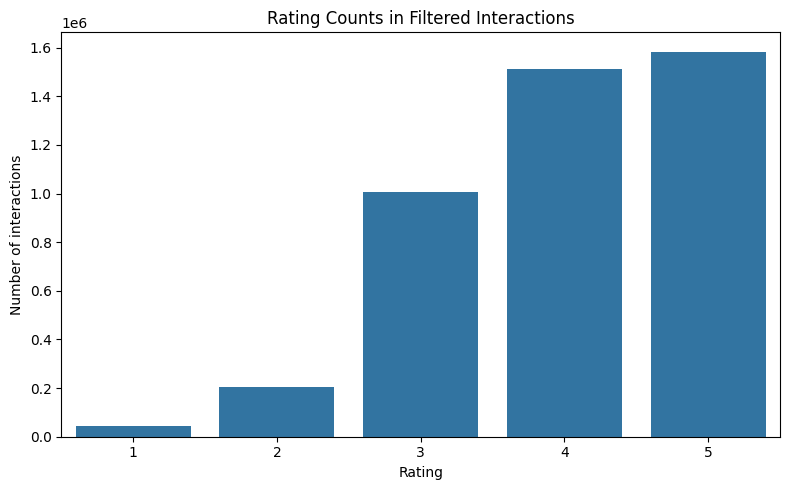

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(data=filtered_interactions, x="rating")
plt.title("Rating Counts in Filtered Interactions")
plt.xlabel("Rating")
plt.ylabel("Number of interactions")
plt.tight_layout()
plt.show()

This code block finds the 10 most-rated books in the filtered interactions and merges the counts with book titles.

In [15]:
top_10_most_rated_books = (
    filtered_interactions["book_id"]
    .value_counts()
    .head(10)
    .rename_axis("book_id")
    .reset_index(name="rating_count")
)

top_10_most_rated_books_with_titles = top_10_most_rated_books.merge(
    books[["book_id", "title"]],
    on="book_id",
    how="left",
)

print(top_10_most_rated_books_with_titles.to_string(index=False))

 book_id  rating_count                                                       title
       5         49527 Harry Potter and the Prisoner of Azkaban (Harry Potter, #3)
   24178         35891                                             Charlotte's Web
    3636         34280                                   The Giver (The Giver, #1)
   30119         28876                                     Where the Sidewalk Ends
  370493         27390                                             The Giving Tree
    2998         25957                                           The Secret Garden
   19543         25823                                   Where the Wild Things Are
   23772         24211                                          Green Eggs and Ham
   39988         23571                                                     Matilda
   38709         23111                                           Holes (Holes, #1)


This code block calculates sparsity before and after filtering to show how much of each user-book matrix is empty.

In [16]:
total_possible_interactions_before = unique_users_before * unique_books_before
actual_interactions_before = len(interactions)
sparsity_before = 1 - (actual_interactions_before / total_possible_interactions_before)

total_possible_interactions_after = unique_users_after * unique_books_after
actual_interactions_after = len(filtered_interactions)
sparsity_after = 1 - (actual_interactions_after / total_possible_interactions_after)

print("Total possible interactions before filtering:", total_possible_interactions_before)
print("Actual interactions before filtering:", actual_interactions_before)
print(f"Sparsity before filtering: {sparsity_before:.2%}")

print("Total possible interactions after filtering:", total_possible_interactions_after)
print("Actual interactions after filtering:", actual_interactions_after)
print(f"Sparsity after filtering: {sparsity_after:.2%}")

Total possible interactions before filtering: 67270435890
Actual interactions before filtering: 10059349
Sparsity before filtering: 99.99%
Total possible interactions after filtering: 2206020915
Actual interactions after filtering: 4350204
Sparsity after filtering: 99.80%


Key Insights from EDA



Most users give high ratings, especially 4 and 5, which shows a positive user bias in the data.

The rating distribution is skewed toward higher ratings, so the model sees more examples of liked books than disliked books.

Ratings 1 and 2 are rare, which means the dataset has very little direct negative feedback from users.

The dataset is highly sparse, around 99%+, meaning most users have interacted with only a tiny fraction of all available books.

Filtering reduced sparsity and removed noisy users or books with very little activity, which improves the quality of the data.

Keeping users with at least 20 ratings and books with at least 50 ratings helps the model learn stronger user-book patterns.

Rating 0 represented implicit interactions, so it was removed from explicit rating analysis but can still be useful for ranking models like LightFM.